In [1]:
import pandas as pd

df = pd.read_csv("Telco-Customer-Churn(in).csv", sep=";")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape

(7043, 21)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

In [6]:
# Load dataset (semicolon-separated)

In [7]:
df = pd.read_csv("Telco-Customer-Churn(in).csv", sep=";")


In [8]:
# --- 1. Churn Distribution ---

In [9]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("=== Churn Counts ===")
print(churn_counts)
print("\n=== Churn Percentage ===")
print(churn_pct.round(2).astype(str) + '%')

=== Churn Counts ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64

=== Churn Percentage ===
Churn
No     73.46%
Yes    26.54%
Name: proportion, dtype: str


C:\Users\dioni\AppData\Local\Temp\ipykernel_19044\2383555815.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette=['#2ecc71', '#e74c3c'], ax=axes[0])


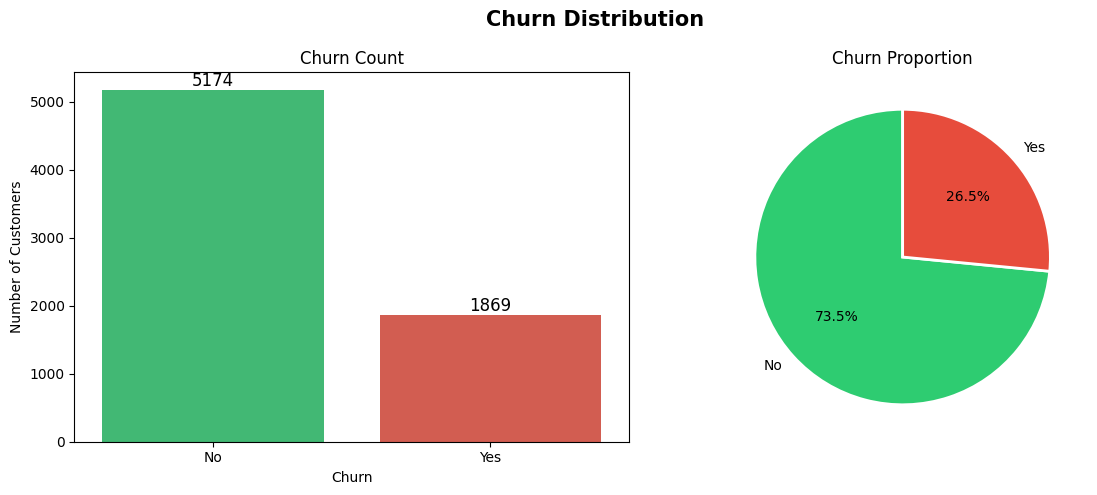

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Churn Distribution', fontsize=15, fontweight='bold')

# Count plot
sns.countplot(data=df, x='Churn', palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Churn Count')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12)

# Pie chart
axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Proportion')

plt.tight_layout()
plt.show()

C:\Users\dioni\AppData\Local\Temp\ipykernel_19044\803318778.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure',


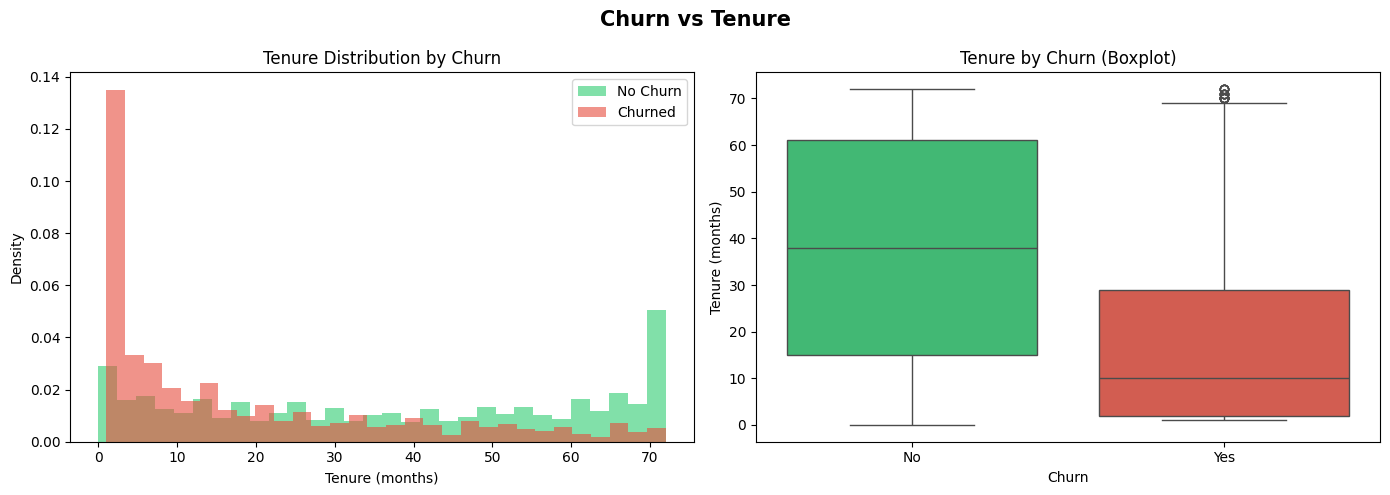

        count   mean    std  min   25%   50%   75%   max
Churn                                                   
No     5174.0  37.57  24.11  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.98  19.53  1.0   2.0  10.0  29.0  72.0


In [11]:
# Ensure tenure is numeric
df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Churn vs Tenure', fontsize=15, fontweight='bold')

# KDE plot
for churn_val, color, label in [('No', '#2ecc71', 'No Churn'), ('Yes', '#e74c3c', 'Churned')]:
    subset = df[df['Churn'] == churn_val]['tenure']
    axes[0].hist(subset, bins=30, alpha=0.6, color=color, label=label, density=True)
axes[0].set_title('Tenure Distribution by Churn')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Box plot
sns.boxplot(data=df, x='Churn', y='tenure',
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, ax=axes[1])
axes[1].set_title('Tenure by Churn (Boxplot)')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Tenure (months)')

plt.tight_layout()
plt.show()

print(df.groupby('Churn')['tenure'].describe().round(2))

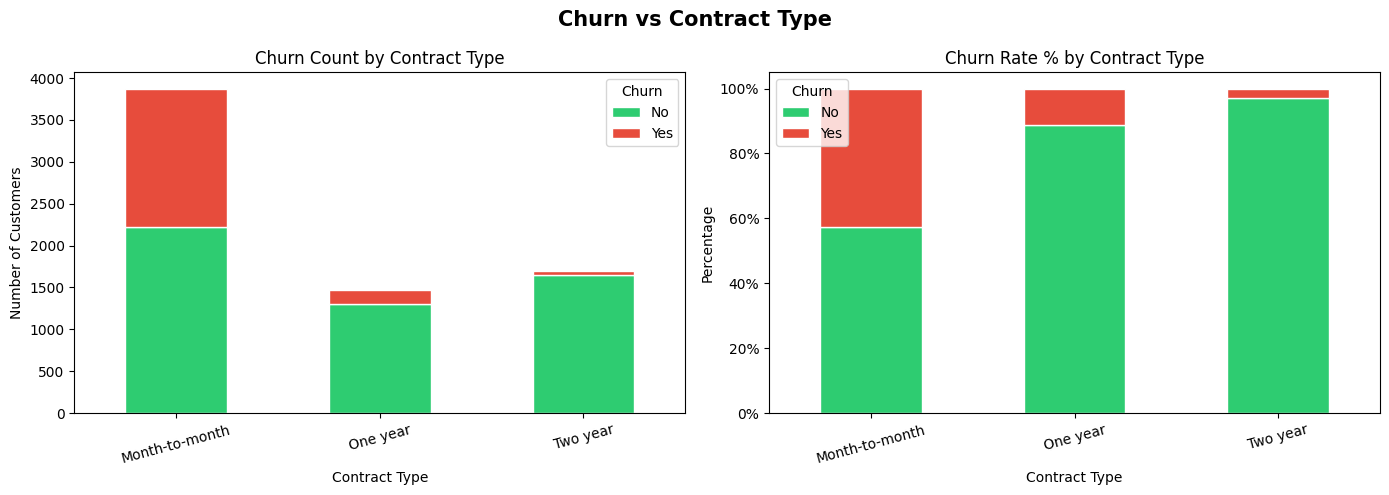

Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Churn vs Contract Type', fontsize=15, fontweight='bold')

# Stacked bar - absolute counts
contract_churn = df.groupby(['Contract', 'Churn']).size().unstack()
contract_churn.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'],
                    ax=axes[0], rot=15, edgecolor='white')
axes[0].set_title('Churn Count by Contract Type')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Number of Customers')
axes[0].legend(title='Churn')

# Stacked bar - percentage
contract_churn_pct = contract_churn.div(contract_churn.sum(axis=1), axis=0) * 100
contract_churn_pct.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'],
                        ax=axes[1], rot=15, edgecolor='white')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title('Churn Rate % by Contract Type')
axes[1].set_xlabel('Contract Type')
axes[1].set_ylabel('Percentage')
axes[1].legend(title='Churn')

plt.tight_layout()
plt.show()

print(contract_churn_pct.round(1))

C:\Users\dioni\AppData\Local\Temp\ipykernel_19044\3744388828.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Churn', y='MonthlyCharges',


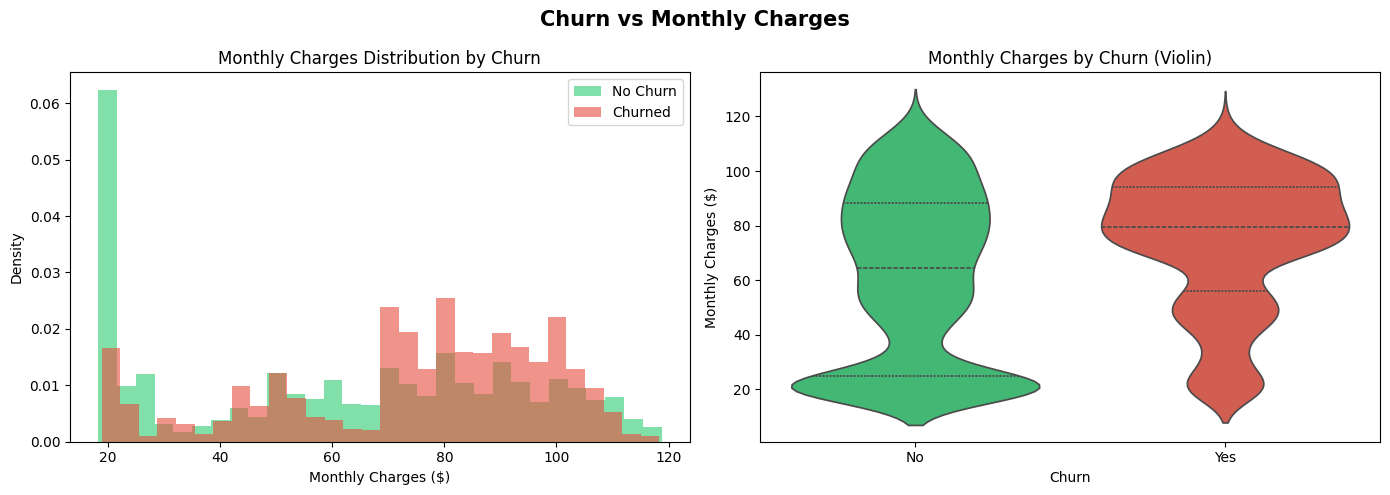

        count   mean    std    min    25%    50%   75%     max
Churn                                                         
No     5174.0  61.27  31.09  18.25  25.10  64.43  88.4  118.75
Yes    1869.0  74.44  24.67  18.85  56.15  79.65  94.2  118.35


In [13]:
# Ensure MonthlyCharges is numeric
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Churn vs Monthly Charges', fontsize=15, fontweight='bold')

# Histogram overlay
for churn_val, color, label in [('No', '#2ecc71', 'No Churn'), ('Yes', '#e74c3c', 'Churned')]:
    subset = df[df['Churn'] == churn_val]['MonthlyCharges']
    axes[0].hist(subset, bins=30, alpha=0.6, color=color, label=label, density=True)
axes[0].set_title('Monthly Charges Distribution by Churn')
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Violin plot
sns.violinplot(data=df, x='Churn', y='MonthlyCharges',
               palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, ax=axes[1],
               inner='quartile')
axes[1].set_title('Monthly Charges by Churn (Violin)')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Monthly Charges ($)')

plt.tight_layout()
plt.show()

print(df.groupby('Churn')['MonthlyCharges'].describe().round(2))

In [14]:
# Ensure correct dtypes first
df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce')
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Separate variable types
numerical_vars = ['tenure', 'MonthlyCharges', 'TotalCharges']

categorical_vars = [col for col in df.columns 
                    if col not in numerical_vars + ['customerID', 'Churn']]

print("Numerical variables:", numerical_vars)
print(f"\nCategorical variables ({len(categorical_vars)}):", categorical_vars)

Numerical variables: ['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical variables (16): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [15]:
from scipy import stats

print("=== Normality Test (Shapiro-Wilk) per variable per Churn group ===\n")

for var in numerical_vars:
    print(f"--- {var} ---")
    for group in ['No', 'Yes']:
        sample = df[df['Churn'] == group][var].dropna()
        # Shapiro works best on samples < 5000 — subsample if needed
        if len(sample) > 5000:
            sample = sample.sample(5000, random_state=42)
        stat, p = stats.shapiro(sample)
        normal = "✅ Normal" if p > 0.05 else "❌ Not Normal"
        print(f"  Churn={group}: W={stat:.4f}, p={p:.4f} → {normal}")
    print()

=== Normality Test (Shapiro-Wilk) per variable per Churn group ===

--- tenure ---
  Churn=No: W=0.9182, p=0.0000 → ❌ Not Normal
  Churn=Yes: W=0.8200, p=0.0000 → ❌ Not Normal

--- MonthlyCharges ---
  Churn=No: W=0.9129, p=0.0000 → ❌ Not Normal
  Churn=Yes: W=0.9284, p=0.0000 → ❌ Not Normal

--- TotalCharges ---
  Churn=No: W=0.8842, p=0.0000 → ❌ Not Normal
  Churn=Yes: W=0.7787, p=0.0000 → ❌ Not Normal



In [16]:
from scipy.stats import mannwhitneyu

print("=== Mann-Whitney U Test: Numerical Variables vs Churn ===\n")

numerical_results = []

for var in numerical_vars:
    group_no  = df[df['Churn'] == 'No'][var].dropna()
    group_yes = df[df['Churn'] == 'Yes'][var].dropna()
    
    stat, p = mannwhitneyu(group_no, group_yes, alternative='two-sided')
    significant = '✅ Yes' if p < 0.05 else '❌ No'
    
    median_no  = group_no.median()
    median_yes = group_yes.median()
    
    print(f"{var}")
    print(f"  Median (No Churn): {median_no:.2f} | Median (Churned): {median_yes:.2f}")
    print(f"  U={stat:.0f}, p={p:.6f} → Significant: {significant}\n")
    
    numerical_results.append({
        'Variable': var,
        'Test': 'Mann-Whitney U',
        'p-value': round(p, 6),
        'Significant': 'Yes' if p < 0.05 else 'No'
    })

=== Mann-Whitney U Test: Numerical Variables vs Churn ===

tenure
  Median (No Churn): 38.00 | Median (Churned): 10.00
  U=7154668, p=0.000000 → Significant: ✅ Yes

MonthlyCharges
  Median (No Churn): 64.43 | Median (Churned): 79.65
  U=3667080, p=0.000000 → Significant: ✅ Yes

TotalCharges
  Median (No Churn): 1683.60 | Median (Churned): 703.55
  U=6288982, p=0.000000 → Significant: ✅ Yes



In [17]:
from scipy.stats import chi2_contingency

print("=== Chi-Square Test: Categorical Variables vs Churn ===\n")

categorical_results = []

for var in categorical_vars:
    contingency_table = pd.crosstab(df[var], df['Churn'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    significant = '✅ Yes' if p < 0.05 else '❌ No'
    
    print(f"{var}: χ²={chi2:.2f}, dof={dof}, p={p:.6f} → Significant: {significant}")
    
    categorical_results.append({
        'Variable': var,
        'Test': 'Chi-Square',
        'p-value': round(p, 6),
        'Significant': 'Yes' if p < 0.05 else 'No'
    })

=== Chi-Square Test: Categorical Variables vs Churn ===

gender: χ²=0.48, dof=1, p=0.486579 → Significant: ❌ No
SeniorCitizen: χ²=159.43, dof=1, p=0.000000 → Significant: ✅ Yes
Partner: χ²=158.73, dof=1, p=0.000000 → Significant: ✅ Yes
Dependents: χ²=189.13, dof=1, p=0.000000 → Significant: ✅ Yes
PhoneService: χ²=0.92, dof=1, p=0.338783 → Significant: ❌ No
MultipleLines: χ²=11.33, dof=2, p=0.003464 → Significant: ✅ Yes
InternetService: χ²=732.31, dof=2, p=0.000000 → Significant: ✅ Yes
OnlineSecurity: χ²=850.00, dof=2, p=0.000000 → Significant: ✅ Yes
OnlineBackup: χ²=601.81, dof=2, p=0.000000 → Significant: ✅ Yes
DeviceProtection: χ²=558.42, dof=2, p=0.000000 → Significant: ✅ Yes
TechSupport: χ²=828.20, dof=2, p=0.000000 → Significant: ✅ Yes
StreamingTV: χ²=374.20, dof=2, p=0.000000 → Significant: ✅ Yes
StreamingMovies: χ²=375.66, dof=2, p=0.000000 → Significant: ✅ Yes
Contract: χ²=1184.60, dof=2, p=0.000000 → Significant: ✅ Yes
PaperlessBilling: χ²=258.28, dof=1, p=0.000000 → Significa

In [18]:
# Combine results
all_results = numerical_results + categorical_results
summary_df = pd.DataFrame(all_results)

# Sort by p-value
summary_df = summary_df.sort_values('p-value').reset_index(drop=True)

# Style the table
def highlight_significant(row):
    if row['Significant'] == 'Yes':
        return ['background-color: #d4edda'] * len(row)
    else:
        return ['background-color: #f8d7da'] * len(row)

print("=== STATISTICAL TESTING SUMMARY ===\n")
summary_df.style.apply(highlight_significant, axis=1)

=== STATISTICAL TESTING SUMMARY ===



,Variable,Test,p-value,Significant
0,tenure,Mann-Whitney U,0.000000,Yes
1,MonthlyCharges,Mann-Whitney U,0.000000,Yes
2,TotalCharges,Mann-Whitney U,0.000000,Yes
3,SeniorCitizen,Chi-Square,0.000000,Yes
4,Dependents,Chi-Square,0.000000,Yes
5,Partner,Chi-Square,0.000000,Yes
6,OnlineSecurity,Chi-Square,0.000000,Yes
7,InternetService,Chi-Square,0.000000,Yes
8,StreamingTV,Chi-Square,0.000000,Yes
9,TechSupport,Chi-Square,0.000000,Yes


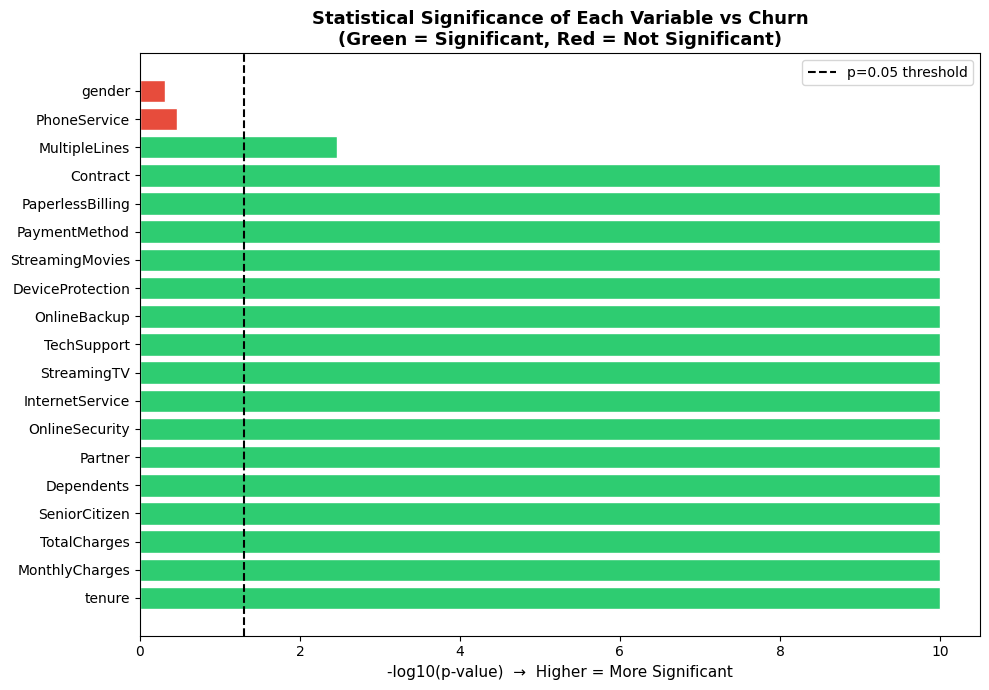

In [19]:
import numpy as np

fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#2ecc71' if s == 'Yes' else '#e74c3c' 
          for s in summary_df['Significant']]

bars = ax.barh(summary_df['Variable'], 
               -np.log10(summary_df['p-value'] + 1e-10),
               color=colors, edgecolor='white')

ax.axvline(x=-np.log10(0.05), color='black', 
           linestyle='--', linewidth=1.5, label='p=0.05 threshold')

ax.set_xlabel('-log10(p-value)  →  Higher = More Significant', fontsize=11)
ax.set_title('Statistical Significance of Each Variable vs Churn\n(Green = Significant, Red = Not Significant)', 
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

                tenure  MonthlyCharges  TotalCharges
tenure           1.000           0.248         0.826
MonthlyCharges   0.248           1.000         0.651
TotalCharges     0.826           0.651         1.000


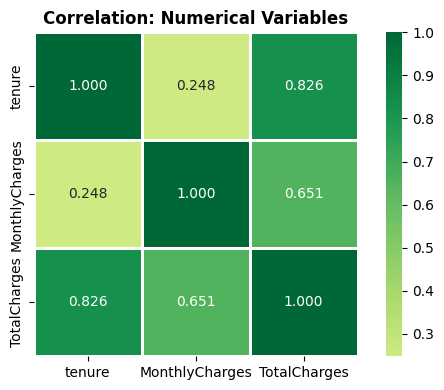

In [20]:
# Έλεγχος correlation μεταξύ numerical variables
import numpy as np

corr_matrix = df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()
print(corr_matrix.round(3))

# Οπτικοποίηση
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', 
            cmap='RdYlGn', center=0,
            square=True, linewidths=2, ax=ax)
ax.set_title('Correlation: Numerical Variables', fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# Drop TotalCharges (high multicollinearity with tenure: r=0.826)
# Drop customerID (unique identifier, no predictive value)
# Drop gender and PhoneService (statistically insignificant: p>0.05)
df_model = df.drop(columns=['TotalCharges', 'customerID', 
                             'gender', 'PhoneService'])

print(f"Original shape : {df.shape}")
print(f"Model df shape : {df_model.shape}")
print(f"\nFinal features ({df_model.shape[1]-1} predictors + 1 target):")
print([col for col in df_model.columns if col != 'Churn'])

Original shape : (7043, 21)
Model df shape : (7043, 17)

Final features (16 predictors + 1 target):
['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges']


In [22]:
from sklearn.preprocessing import LabelEncoder

# Work from df_model (already dropped TotalCharges, customerID, gender, PhoneService)
# Make a clean copy
df_lr = df_model.copy()

# Encode target variable: No=0, Yes=1
df_lr['Churn'] = (df_lr['Churn'] == 'Yes').astype(int)

print("Target distribution:")
print(df_lr['Churn'].value_counts())
print(f"\nChurn rate: {df_lr['Churn'].mean()*100:.1f}%")
print(f"\nShape: {df_lr.shape}")
print(f"\nDtypes:\n{df_lr.dtypes}")

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.5%

Shape: (7043, 17)

Dtypes:
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
Churn                 int64
dtype: object


In [23]:
# Identify binary vs multi-category columns
binary_cols = [col for col in df_lr.select_dtypes(include='object').columns
               if df_lr[col].nunique() == 2]

multi_cols = [col for col in df_lr.select_dtypes(include='object').columns
              if df_lr[col].nunique() > 2]

print("Binary columns (Label Encoding):", binary_cols)
print("Multi-category columns (One-Hot Encoding):", multi_cols)

# Label encode binary columns (0/1)
le = LabelEncoder()
for col in binary_cols:
    df_lr[col] = le.fit_transform(df_lr[col])
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# One-hot encode multi-category columns
df_lr = pd.get_dummies(df_lr, columns=multi_cols, drop_first=True)

print(f"\nShape after encoding: {df_lr.shape}")
print(f"Columns: {list(df_lr.columns)}")

Binary columns (Label Encoding): ['Partner', 'Dependents', 'PaperlessBilling']
Multi-category columns (One-Hot Encoding): ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
  Partner: {'No': np.int64(0), 'Yes': np.int64(1)}
  Dependents: {'No': np.int64(0), 'Yes': np.int64(1)}
  PaperlessBilling: {'No': np.int64(0), 'Yes': np.int64(1)}

Shape after encoding: (7043, 28)
Columns: ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PaperlessBilling', 'MonthlyCharges', 'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'Stre

C:\Users\dioni\AppData\Local\Temp\ipykernel_19044\936545569.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  binary_cols = [col for col in df_lr.select_dtypes(include='object').columns
C:\Users\dioni\AppData\Local\Temp\ipykernel_19044\936545569.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.o

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df_lr.drop(columns=['Churn'])
y = df_lr['Churn']

# Split BEFORE scaling — critical to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # reproducibility
    stratify=y           # maintain churn ratio in both sets
)

print(f"Training set   : {X_train.shape[0]} rows ({y_train.mean()*100:.1f}% churn)")
print(f"Test set       : {X_test.shape[0]} rows ({y_test.mean()*100:.1f}% churn)")
print(f"Features       : {X_train.shape[1]}")



Training set   : 5634 rows (26.5% churn)
Test set       : 1409 rows (26.5% churn)
Features       : 27


In [25]:
# Scale ONLY numerical columns
num_cols = ['tenure', 'MonthlyCharges']

scaler = StandardScaler()

# Fit on TRAIN only — then transform both
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])   # NO fit here

print("Scaling complete.")
print(f"\nTrain tenure   — mean: {X_train['tenure'].mean():.3f}, std: {X_train['tenure'].std():.3f}")
print(f"Test  tenure   — mean: {X_test['tenure'].mean():.3f},  std: {X_test['tenure'].std():.3f}")

Scaling complete.

Train tenure   — mean: -0.000, std: 1.000
Test  tenure   — mean: -0.023,  std: 0.998


In [26]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    class_weight='balanced',  # handles 73/27 imbalance
    max_iter=1000,            # ensure convergence
    random_state=42,
    solver='lbfgs'
)

lr_model.fit(X_train, y_train)

print("✅ Model trained successfully.")
print(f"   Features used : {X_train.shape[1]}")
print(f"   Training rows : {X_train.shape[0]}")

✅ Model trained successfully.
   Features used : 27
   Training rows : 5634


        MODEL EVALUATION — TEST SET
  Accuracy  : 0.753 (train) | 0.743 (test)
  Precision : 0.511
  Recall    : 0.778
  F1-Score  : 0.617
  ROC-AUC   : 0.839


C:\Users\dioni\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


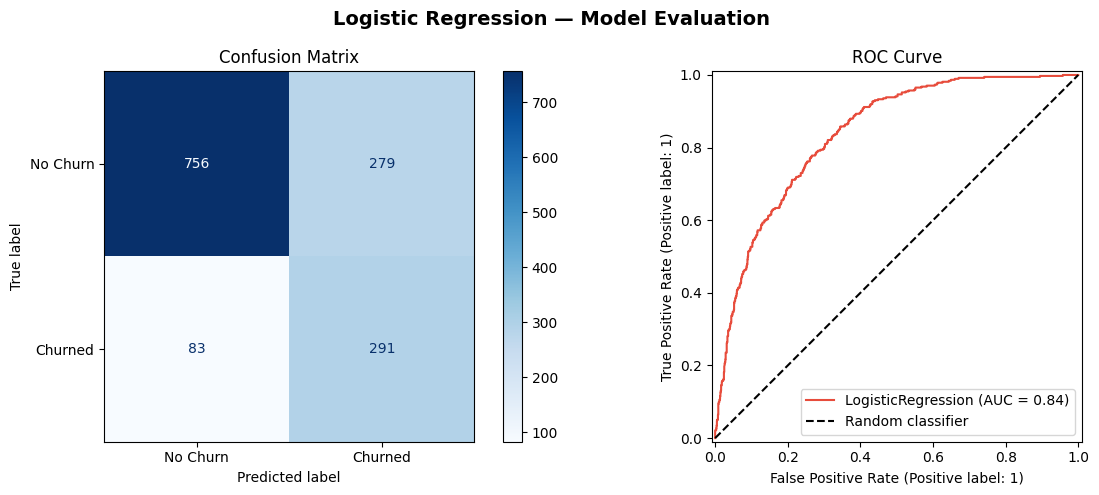

In [27]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score,
                              ConfusionMatrixDisplay, RocCurveDisplay)

y_pred      = lr_model.predict(X_test)
y_pred_prob = lr_model.predict_proba(X_test)[:, 1]

# --- Metrics ---
print("=" * 45)
print("        MODEL EVALUATION — TEST SET")
print("=" * 45)
print(f"  Accuracy  : {accuracy_score(y_train, lr_model.predict(X_train)):.3f} (train) | "
      f"{accuracy_score(y_test, y_pred):.3f} (test)")
print(f"  Precision : {precision_score(y_test, y_pred):.3f}")
print(f"  Recall    : {recall_score(y_test, y_pred):.3f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred):.3f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_pred_prob):.3f}")
print("=" * 45)

# --- Confusion Matrix + ROC Curve ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Logistic Regression — Model Evaluation', 
             fontsize=14, fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No Churn', 'Churned'],
    cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')

RocCurveDisplay.from_estimator(
    lr_model, X_test, y_test, ax=axes[1], color='#e74c3c')
axes[1].plot([0,1],[0,1], 'k--', label='Random classifier')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

=== TOP CHURN DRIVERS (Positive = increases churn risk) ===

                              Feature  Coefficient  Odds Ratio
          InternetService_Fiber optic     1.280025    3.596730
                  StreamingMovies_Yes     0.457951    1.580832
                      StreamingTV_Yes     0.435197    1.545268
       PaymentMethod_Electronic check     0.404140    1.498013
                    MultipleLines_Yes     0.358964    1.431845
                     PaperlessBilling     0.333926    1.396439
                        SeniorCitizen     0.155014    1.167675
       MultipleLines_No phone service     0.100533    1.105760
           PaymentMethod_Mailed check     0.091382    1.095687
                 DeviceProtection_Yes     0.072038    1.074696
                              Partner     0.012213    1.012288
PaymentMethod_Credit card (automatic)     0.000868    1.000868
                     OnlineBackup_Yes    -0.037963    0.962749
     OnlineBackup_No internet service    -0.175372    0.8

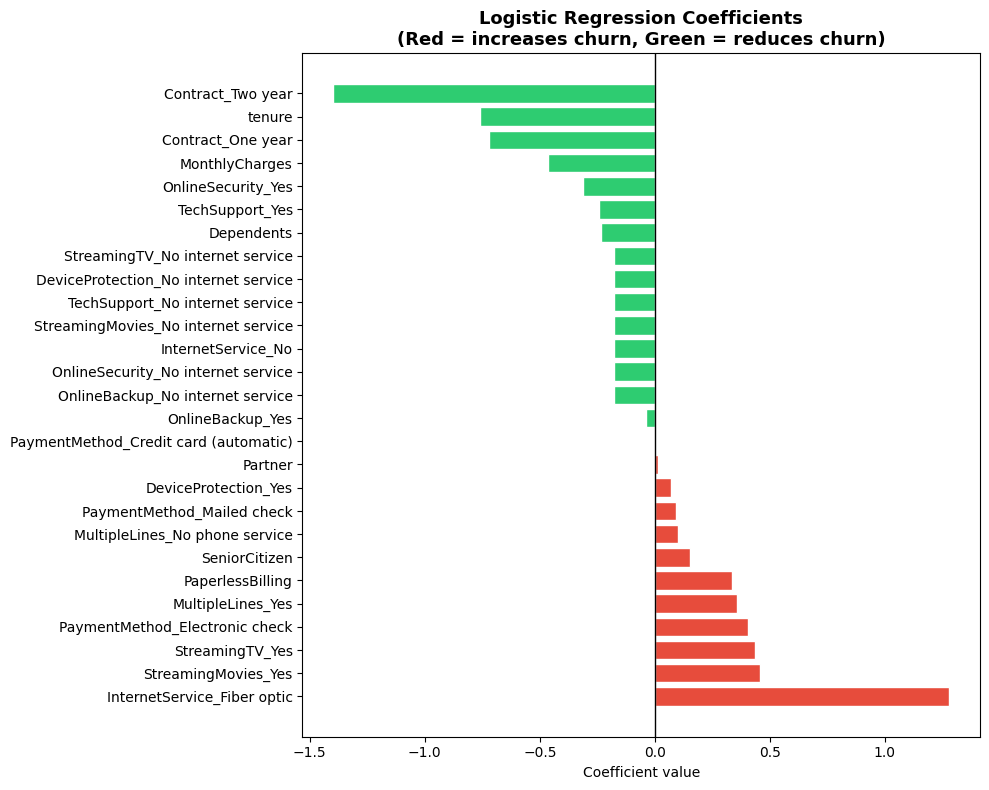

In [28]:
# Build coefficients dataframe
coef_df = pd.DataFrame({
    'Feature'    : X_train.columns,
    'Coefficient': lr_model.coef_[0],
    'Odds Ratio' : np.exp(lr_model.coef_[0])
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)

print("=== TOP CHURN DRIVERS (Positive = increases churn risk) ===\n")
print(coef_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=1)
ax.set_title('Logistic Regression Coefficients\n(Red = increases churn, Green = reduces churn)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient value')
plt.tight_layout()
plt.show()

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,        # 200 decision trees
    class_weight='balanced', # handle 73/27 imbalance
    random_state=42,
    n_jobs=-1                # use all CPU cores
)

rf_model.fit(X_train, y_train)

print("✅ Random Forest trained successfully.")
print(f"   Trees          : {rf_model.n_estimators}")
print(f"   Features used  : {X_train.shape[1]}")
print(f"   Training rows  : {X_train.shape[0]}")

✅ Random Forest trained successfully.
   Trees          : 200
   Features used  : 27
   Training rows  : 5634


In [30]:
# Logistic Regression predictions (already trained)
lr_pred       = lr_model.predict(X_test)
lr_pred_prob  = lr_model.predict_proba(X_test)[:, 1]

# Random Forest predictions
rf_pred       = rf_model.predict(X_test)
rf_pred_prob  = rf_model.predict_proba(X_test)[:, 1]

print("✅ Predictions generated for both models.")
print(f"\nLR  — Predicted churners : {lr_pred.sum()}")
print(f"RF  — Predicted churners : {rf_pred.sum()}")
print(f"Actual churners          : {y_test.sum()}")

✅ Predictions generated for both models.

LR  — Predicted churners : 570
RF  — Predicted churners : 292
Actual churners          : 374


In [31]:
from sklearn.metrics import (accuracy_score, precision_score, 
                              recall_score, f1_score, roc_auc_score)

def get_metrics(name, y_true, y_pred, y_prob):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 3),
        'Precision': round(precision_score(y_true, y_pred), 3),
        'Recall'   : round(recall_score(y_true, y_pred), 3),
        'F1-Score' : round(f1_score(y_true, y_pred), 3),
        'ROC-AUC'  : round(roc_auc_score(y_true, y_prob), 3)
    }

results = pd.DataFrame([
    get_metrics('Logistic Regression', y_test, lr_pred, lr_pred_prob),
    get_metrics('Random Forest',       y_test, rf_pred, rf_pred_prob),
])

results = results.set_index('Model')

print("=" * 62)
print("           MODEL COMPARISON — TEST SET")
print("=" * 62)
print(results.to_string())
print("=" * 62)

results.style.highlight_max(axis=0, color='#d4edda') \
             .highlight_min(axis=0, color='#f8d7da') \
             .format("{:.3f}") 

           MODEL COMPARISON — TEST SET
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression     0.743      0.511   0.778     0.617    0.839
Random Forest           0.781      0.613   0.479     0.538    0.820


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.743,0.511,0.778,0.617,0.839
Random Forest,0.781,0.613,0.479,0.538,0.820


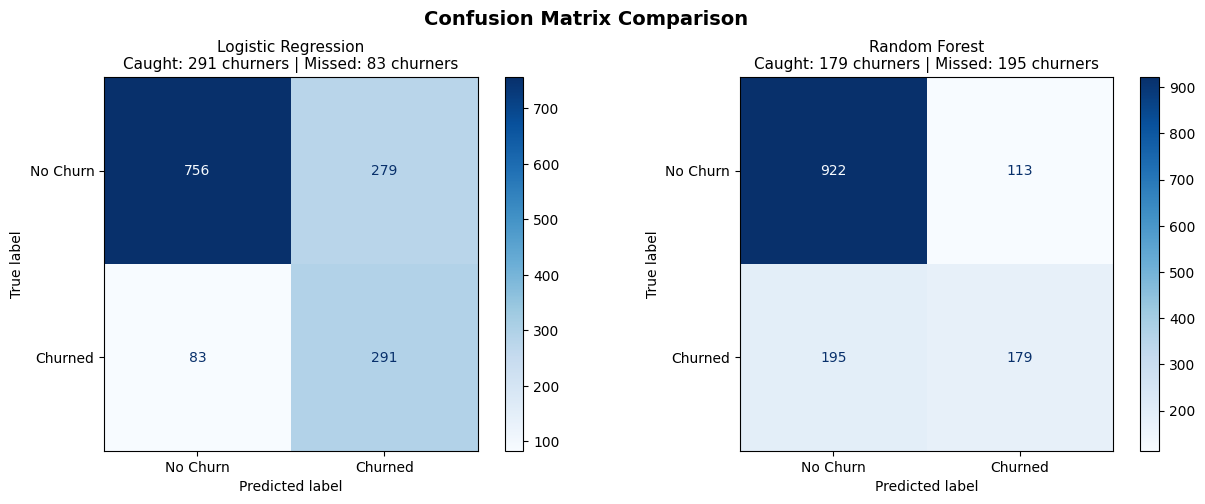

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrix Comparison', 
             fontsize=14, fontweight='bold')

for ax, model, preds, name in zip(
    axes,
    [lr_model, rf_model],
    [lr_pred,  rf_pred],
    ['Logistic Regression', 'Random Forest']
):
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds,
        display_labels=['No Churn', 'Churned'],
        cmap='Blues', ax=ax
    )
    
    tn, fp, fn, tp = __import__('sklearn.metrics', 
                     fromlist=['confusion_matrix'])\
                     .confusion_matrix(y_test, preds).ravel()
    
    ax.set_title(f'{name}\n'
                 f'Caught: {tp} churners | Missed: {fn} churners',
                 fontsize=11)

plt.tight_layout()
plt.show()

C:\Users\dioni\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\dioni\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


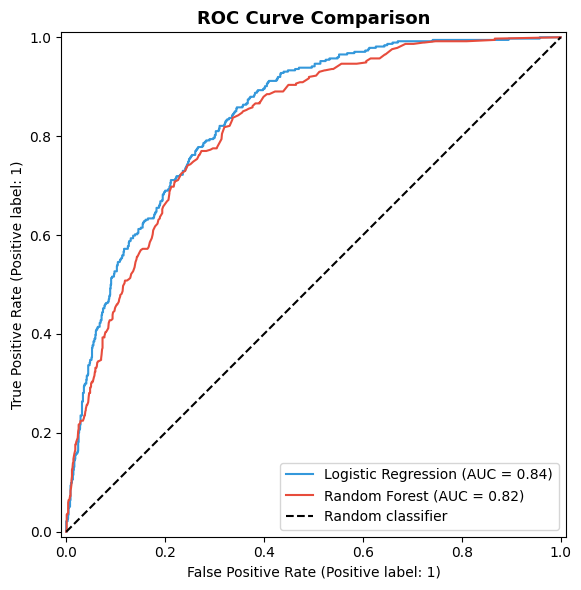

In [33]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(
    lr_model, X_test, y_test, ax=ax,
    color='#3498db', name='Logistic Regression')

RocCurveDisplay.from_estimator(
    rf_model, X_test, y_test, ax=ax,
    color='#e74c3c', name='Random Forest')

ax.plot([0,1], [0,1], 'k--', label='Random classifier')
ax.set_title('ROC Curve Comparison', 
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

=== TOP 15 FEATURES — Random Forest ===

                       Feature  Importance
                        tenure    0.238384
                MonthlyCharges    0.216715
             Contract_Two year    0.071741
   InternetService_Fiber optic    0.046025
PaymentMethod_Electronic check    0.038278
             Contract_One year    0.035714
            OnlineSecurity_Yes    0.030101
              PaperlessBilling    0.027792
               TechSupport_Yes    0.027762
                       Partner    0.026679
              OnlineBackup_Yes    0.024982
                    Dependents    0.023031
          DeviceProtection_Yes    0.021921
                 SeniorCitizen    0.021646
             MultipleLines_Yes    0.020818


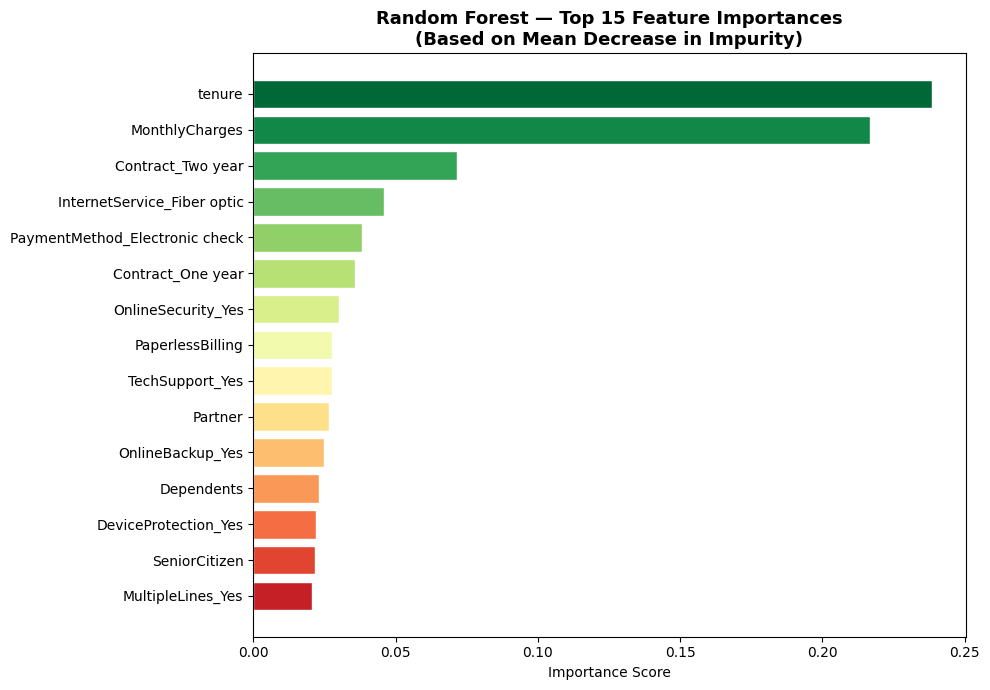

In [34]:
# Random Forest feature importance
rf_importance = pd.DataFrame({
    'Feature'   : X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("=== TOP 15 FEATURES — Random Forest ===\n")
print(rf_importance.head(15).to_string(index=False))

# Plot top 15
fig, ax = plt.subplots(figsize=(10, 7))
top15 = rf_importance.head(15)

colors = plt.cm.RdYlGn_r(
    [i/len(top15) for i in range(len(top15))])

ax.barh(top15['Feature'][::-1], 
        top15['Importance'][::-1],
        color=colors[::-1], edgecolor='white')

ax.set_title('Random Forest — Top 15 Feature Importances\n'
             '(Based on Mean Decrease in Impurity)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

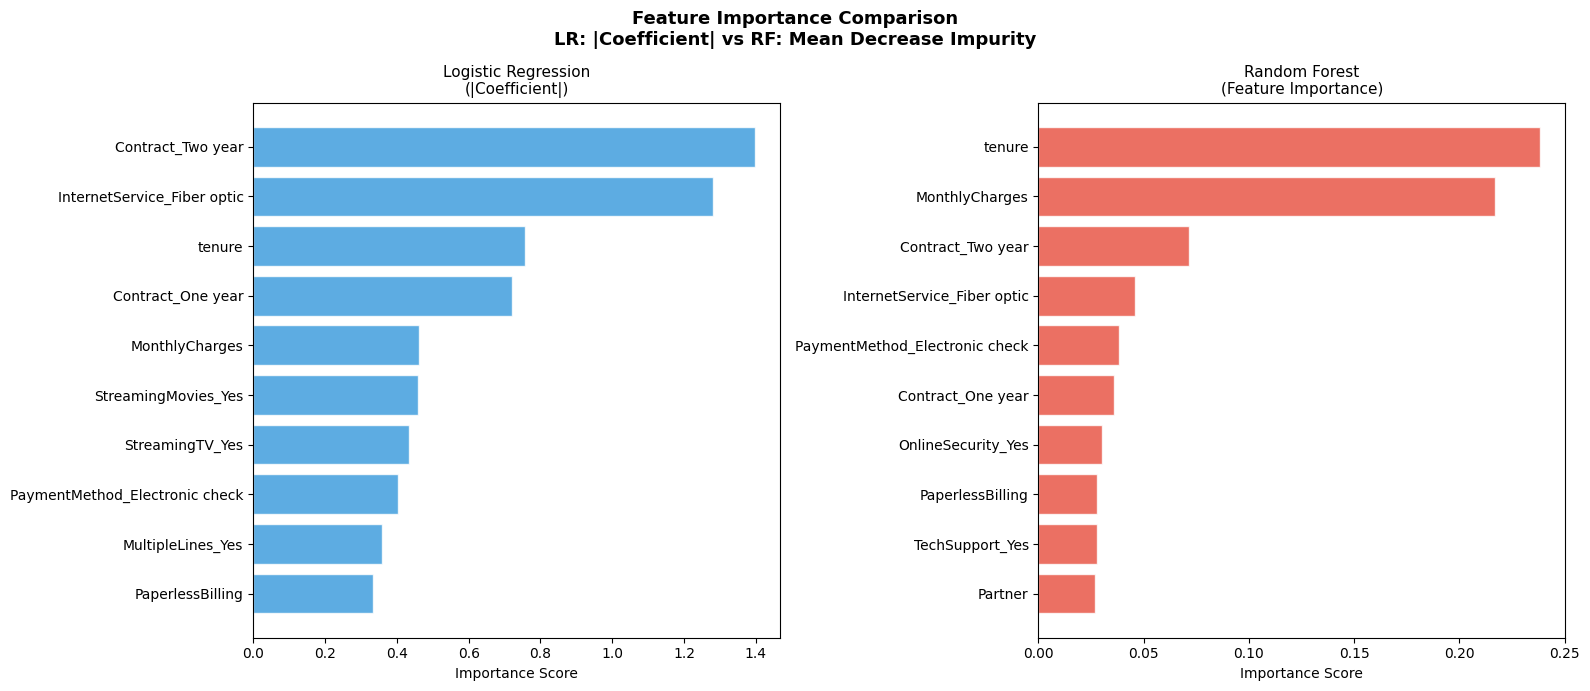

In [35]:
# LR uses absolute coefficients as proxy for importance
lr_importance = pd.DataFrame({
    'Feature'   : X_train.columns,
    'Importance': np.abs(lr_model.coef_[0])
}).sort_values('Importance', ascending=False).reset_index(drop=True)

# Merge top 10 from each
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Feature Importance Comparison\n'
             'LR: |Coefficient| vs RF: Mean Decrease Impurity',
             fontsize=13, fontweight='bold')

for ax, imp_df, name, color in zip(
    axes,
    [lr_importance, rf_importance],
    ['Logistic Regression\n(|Coefficient|)', 
     'Random Forest\n(Feature Importance)'],
    ['#3498db', '#e74c3c']
):
    top10 = imp_df.head(10)
    ax.barh(top10['Feature'][::-1], 
            top10['Importance'][::-1],
            color=color, alpha=0.8, edgecolor='white')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

In [36]:
print("X_train shape    :", X_train.shape)
print("lr_model         :", type(lr_model).__name__)
print("rf_model         :", type(rf_model).__name__)
print("lr_pred_prob[:3] :", lr_pred_prob[:3])
print("rf_pred_prob[:3] :", rf_pred_prob[:3])

X_train shape    : (5634, 27)
lr_model         : LogisticRegression
rf_model         : RandomForestClassifier
lr_pred_prob[:3] : [0.08702038 0.8691917  0.15947716]
rf_pred_prob[:3] : [0.    0.745 0.05 ]


In [37]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

print("Running 10-Fold Cross-Validation... (may take 30-60 seconds)\n")

cv_results = {}
for name, model in [('Logistic Regression', lr_model), 
                     ('Random Forest',       rf_model)]:
    scores = cross_validate(model, X_train, y_train,
                            cv=cv, scoring=scoring,
                            n_jobs=-1)
    cv_results[name] = scores
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    for metric in scoring:
        vals = scores[f'test_{metric}']
        print(f"  {metric:<12}: {vals.mean():.3f} ± {vals.std():.3f}")
    print()

Running 10-Fold Cross-Validation... (may take 30-60 seconds)

  Logistic Regression
  accuracy    : 0.749 ± 0.017
  precision   : 0.518 ± 0.022
  recall      : 0.792 ± 0.035
  f1          : 0.626 ± 0.025
  roc_auc     : 0.845 ± 0.014

  Random Forest
  accuracy    : 0.785 ± 0.012
  precision   : 0.627 ± 0.032
  recall      : 0.477 ± 0.038
  f1          : 0.541 ± 0.029
  roc_auc     : 0.818 ± 0.016



C:\Users\dioni\AppData\Local\Temp\ipykernel_19044\1897123496.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(auc_data, labels=['Logistic\nRegression', 'Random\nForest'],


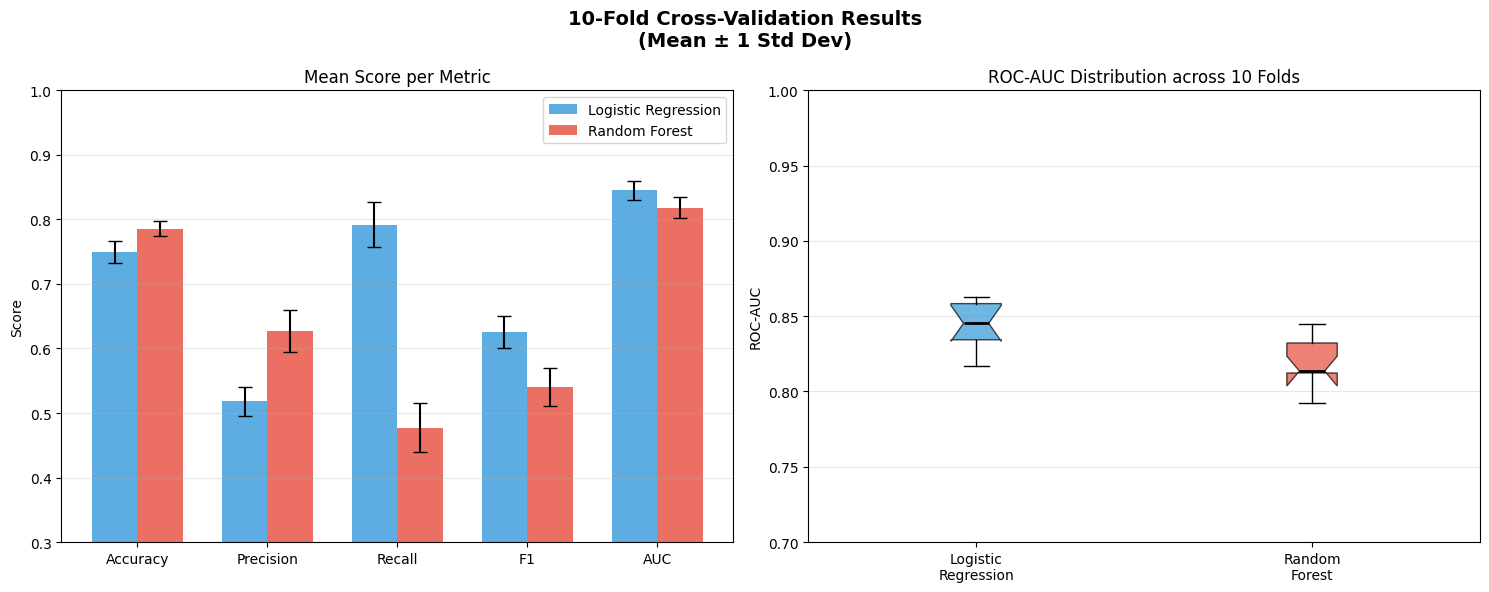

In [38]:
import matplotlib.pyplot as plt
import numpy as np

metrics_labels = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x = np.arange(len(metrics_labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('10-Fold Cross-Validation Results\n(Mean ± 1 Std Dev)', 
             fontsize=14, fontweight='bold')

colors = {'Logistic Regression': '#3498db', 'Random Forest': '#e74c3c'}

# Bar plot with error bars
ax = axes[0]
for i, (name, color) in enumerate(colors.items()):
    means = [cv_results[name][f'test_{m}'].mean() for m in metrics_labels]
    stds  = [cv_results[name][f'test_{m}'].std()  for m in metrics_labels]
    bars = ax.bar(x + i*width, means, width, 
                  yerr=stds, capsize=5,
                  label=name, color=color, alpha=0.8)

ax.set_xticks(x + width/2)
ax.set_xticklabels(['Accuracy','Precision','Recall','F1','AUC'], 
                   fontsize=10)
ax.set_ylabel('Score')
ax.set_ylim(0.3, 1.0)
ax.set_title('Mean Score per Metric')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# AUC distribution boxplot
ax2 = axes[1]
auc_data = [cv_results['Logistic Regression']['test_roc_auc'],
            cv_results['Random Forest']['test_roc_auc']]

bp = ax2.boxplot(auc_data, labels=['Logistic\nRegression', 'Random\nForest'],
                 patch_artist=True, notch=True,
                 medianprops={'color': 'black', 'linewidth': 2})

for patch, color in zip(bp['boxes'], ['#3498db', '#e74c3c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_title('ROC-AUC Distribution across 10 Folds')
ax2.set_ylabel('ROC-AUC')
ax2.set_ylim(0.7, 1.0)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [39]:
!pip install statsmodels


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\dioni\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [40]:
from statsmodels.stats.contingency_tables import mcnemar

# McNemar test: are the two models significantly different?
lr_correct = (lr_pred == y_test.values)
rf_correct = (rf_pred == y_test.values)

# Contingency table
b = np.sum(lr_correct & ~rf_correct)  # LR correct, RF wrong
c = np.sum(~lr_correct & rf_correct)  # LR wrong, RF correct

table = [[np.sum(lr_correct & rf_correct),  b],
         [c, np.sum(~lr_correct & ~rf_correct)]]

result = mcnemar(table, exact=False, correction=True)

print("="*50)
print("   McNemar's Test — LR vs Random Forest")
print("="*50)
print(f"\n  H0: The two models make the same errors")
print(f"  H1: The models differ significantly\n")
print(f"  LR correct, RF wrong  : {b}")
print(f"  RF correct, LR wrong  : {c}")
print(f"\n  χ² statistic : {result.statistic:.4f}")
print(f"  p-value      : {result.pvalue:.4f}")

if result.pvalue < 0.05:
    better = "Logistic Regression" if b > c else "Random Forest"
    print(f"\n  ✅ Significant difference (p<0.05)")
    print(f"  → {better} performs significantly better")
else:
    print(f"\n  ⚠️  No significant difference (p≥0.05)")
    print(f"  → Models are statistically equivalent")
print("="*50)

   McNemar's Test — LR vs Random Forest

  H0: The two models make the same errors
  H1: The models differ significantly

  LR correct, RF wrong  : 124
  RF correct, LR wrong  : 178

  χ² statistic : 9.3013
  p-value      : 0.0023

  ✅ Significant difference (p<0.05)
  → Random Forest performs significantly better


In [41]:
import statsmodels.api as sm
import numpy as np

# Fix column names
def clean_colnames(df):
    df = df.copy()
    df.columns = (df.columns
                  .str.replace(' ', '_', regex=False)
                  .str.replace('(', '',  regex=False)
                  .str.replace(')', '',  regex=False)
                  .str.replace('-', '_', regex=False)
                  .str.replace('/', '_', regex=False)
                  .str.replace('.', '',  regex=False))
    return df

X_train_clean = clean_colnames(X_train).reset_index(drop=True)
y_train_clean = y_train.reset_index(drop=True)

# Remove redundant dummy columns
redundant = [c for c in X_train_clean.columns if 
             c.endswith('_No') or 
             c.endswith('_No_internet_service') or
             c.endswith('_No_phone_service')]

X_train_final = X_train_clean.drop(columns=redundant, errors='ignore')

# Save column names BEFORE converting to numpy
feature_names = ['const'] + list(X_train_final.columns)

# Convert to pure numpy — bypasses ALL statsmodels pandas issues
X_np = np.column_stack([
    np.ones(len(X_train_final)),  # constant/intercept
    X_train_final.values.astype(float)
])
y_np = y_train_clean.values.astype(float)

print(f"X shape: {X_np.shape}")
print(f"y shape: {y_np.shape}")
print(f"Features: {len(feature_names)}")

# Fit using pure numpy arrays
lr_sm = sm.Logit(y_np, X_np).fit(
    method='bfgs', maxiter=1000, disp=False)

# Manually assign feature names to results
lr_sm.model.exog_names[:] = feature_names

print("\n✅ statsmodels fitted successfully.")
print(f"   Observations : {lr_sm.nobs:.0f}")
print(f"   AIC          : {lr_sm.aic:.2f}")
print(f"   BIC          : {lr_sm.bic:.2f}")
print(f"   Pseudo R²    : {lr_sm.prsquared:.4f}")

X shape: (5634, 20)
y shape: (5634,)
Features: 20

✅ statsmodels fitted successfully.
   Observations : 5634
   AIC          : 4754.87
   BIC          : 4887.60
   Pseudo R²    : 0.2768


In [42]:
# Build summary table with feature names
sm_summary = pd.DataFrame({
    'Coefficient' : lr_sm.params[1:],  # skip const
    'Odds Ratio'  : np.exp(lr_sm.params[1:]),
    'CI Lower'    : np.exp(lr_sm.conf_int()[1:, 0]),
    'CI Upper'    : np.exp(lr_sm.conf_int()[1:, 1]),
    'p-value'     : lr_sm.pvalues[1:]
}, index=feature_names[1:]).round(4)

sm_summary['Significant'] = sm_summary['p-value'].apply(
    lambda p: '✅ Yes' if p < 0.05 else '❌ No')

sm_summary = sm_summary.sort_values('Coefficient', ascending=False)

print("="*75)
print("   LOGISTIC REGRESSION — Coefficients, Odds Ratios, 95% CI, p-values")
print("="*75)
print(sm_summary.to_string())
print("="*75)
print(f"\nSignificant features (p<0.05): "
      f"{(sm_summary['p-value'] < 0.05).sum()} / {len(sm_summary)}")

   LOGISTIC REGRESSION — Coefficients, Odds Ratios, 95% CI, p-values
                                     Coefficient  Odds Ratio  CI Lower  CI Upper  p-value Significant
InternetService_Fiber_optic               0.5611      1.7526    1.1889    2.5837   0.0046       ✅ Yes
PaymentMethod_Electronic_check            0.4371      1.5482    1.2592    1.9035   0.0000       ✅ Yes
PaperlessBilling                          0.4273      1.5331    1.3046    1.8017   0.0000       ✅ Yes
MonthlyCharges                            0.3290      1.3896    1.0261    1.8818   0.0335       ✅ Yes
StreamingMovies_Yes                       0.2341      1.2637    1.0295    1.5513   0.0252       ✅ Yes
StreamingTV_Yes                           0.2252      1.2525    1.0191    1.5394   0.0324       ✅ Yes
SeniorCitizen                             0.1883      1.2071    1.0024    1.4536   0.0471       ✅ Yes
MultipleLines_Yes                         0.1813      1.1987    0.9985    1.4391   0.0519        ❌ No
PaymentMethod

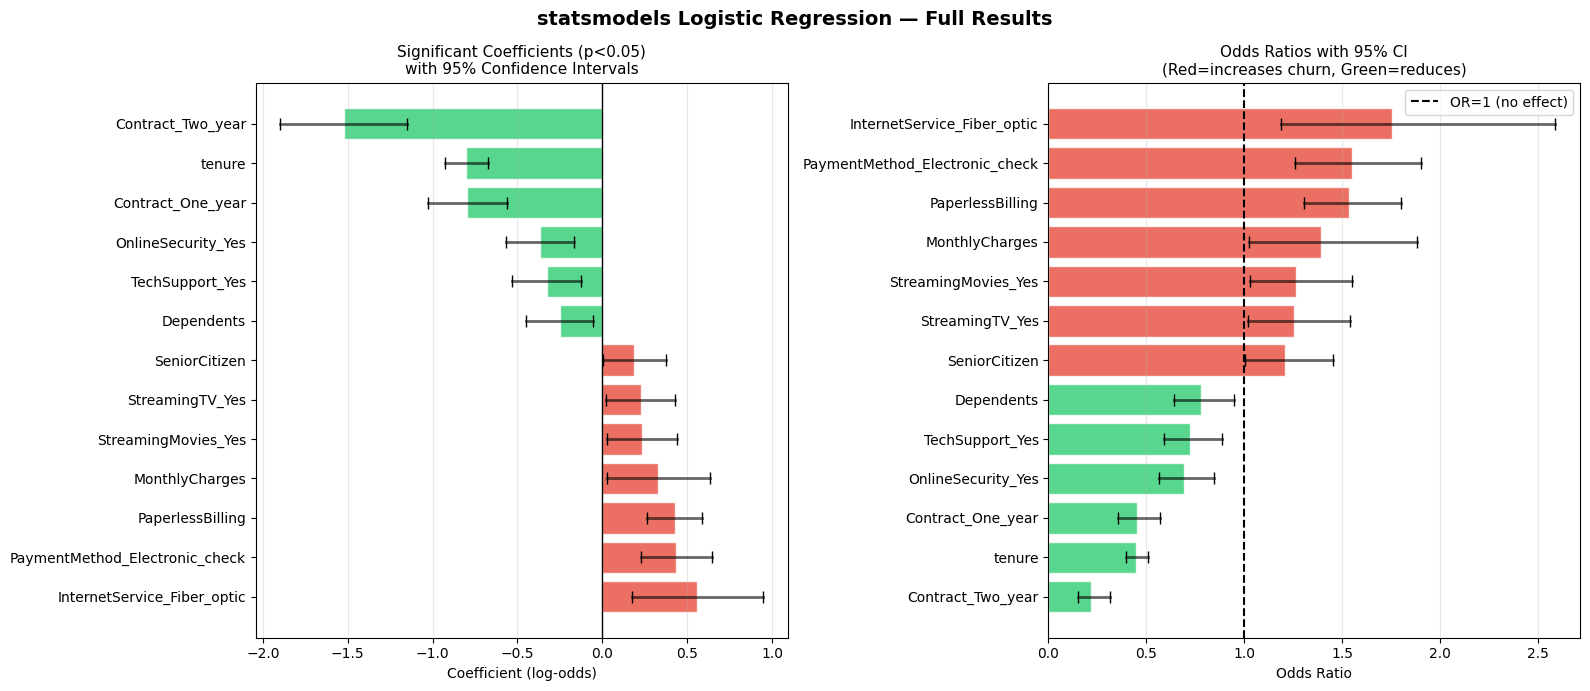

In [43]:
sig = sm_summary[sm_summary['p-value'] < 0.05].copy()
non_sig = sm_summary[sm_summary['p-value'] >= 0.05].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('statsmodels Logistic Regression — Full Results',
             fontsize=14, fontweight='bold')

# --- Plot 1: Coefficients with CI ---
colors = ['#e74c3c' if c > 0 else '#2ecc71' 
          for c in sig['Coefficient']]

y_pos = range(len(sig))
axes[0].barh(list(sig.index), sig['Coefficient'],
             color=colors, alpha=0.8, edgecolor='white')

# Confidence intervals
for i, (idx, row) in enumerate(sig.iterrows()):
    ci_lo = np.log(max(row['CI Lower'], 1e-10))
    ci_hi = np.log(max(row['CI Upper'], 1e-10))
    axes[0].plot([ci_lo, ci_hi], [i, i],
                 'k-', linewidth=2, alpha=0.6)
    axes[0].plot([ci_lo, ci_hi], [i, i],
                 'k|', markersize=8)

axes[0].axvline(x=0, color='black', linewidth=1)
axes[0].set_title('Significant Coefficients (p<0.05)\nwith 95% Confidence Intervals',
                  fontsize=11)
axes[0].set_xlabel('Coefficient (log-odds)')
axes[0].grid(axis='x', alpha=0.3)

# --- Plot 2: Odds Ratios ---
sig_sorted = sig.sort_values('Odds Ratio', ascending=True)
colors_or = ['#e74c3c' if o > 1 else '#2ecc71' 
             for o in sig_sorted['Odds Ratio']]

axes[1].barh(list(sig_sorted.index), sig_sorted['Odds Ratio'],
             color=colors_or, alpha=0.8, edgecolor='white')

# CI for Odds Ratios
for i, (idx, row) in enumerate(sig_sorted.iterrows()):
    axes[1].plot([row['CI Lower'], row['CI Upper']], [i, i],
                 'k-', linewidth=2, alpha=0.6)
    axes[1].plot([row['CI Lower'], row['CI Upper']], [i, i],
                 'k|', markersize=8)

axes[1].axvline(x=1, color='black', linewidth=1.5,
                linestyle='--', label='OR=1 (no effect)')
axes[1].set_title('Odds Ratios with 95% CI\n(Red=increases churn, Green=reduces)',
                  fontsize=11)
axes[1].set_xlabel('Odds Ratio')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [44]:
# Full styled summary
print("\n=== SIGNIFICANT FEATURES (p < 0.05) ===\n")
sig_display = sig[['Coefficient','Odds Ratio',
                    'CI Lower','CI Upper','p-value']].copy()
print(sig_display.to_string())

print("\n=== NON-SIGNIFICANT FEATURES (p ≥ 0.05) ===\n")
print(non_sig[['Coefficient','Odds Ratio','p-value']].to_string())

print(f"\n=== MODEL FIT STATISTICS ===")
print(f"  AIC        : {lr_sm.aic:.2f}")
print(f"  BIC        : {lr_sm.bic:.2f}")
print(f"  Pseudo R²  : {lr_sm.prsquared:.4f}")
print(f"  Log-Lik    : {lr_sm.llf:.2f}")
print(f"  Null Log-L : {lr_sm.llnull:.2f}")
print(f"  LLR p-val  : {lr_sm.llr_pvalue:.6f}")


=== SIGNIFICANT FEATURES (p < 0.05) ===

                                Coefficient  Odds Ratio  CI Lower  CI Upper  p-value
InternetService_Fiber_optic          0.5611      1.7526    1.1889    2.5837   0.0046
PaymentMethod_Electronic_check       0.4371      1.5482    1.2592    1.9035   0.0000
PaperlessBilling                     0.4273      1.5331    1.3046    1.8017   0.0000
MonthlyCharges                       0.3290      1.3896    1.0261    1.8818   0.0335
StreamingMovies_Yes                  0.2341      1.2637    1.0295    1.5513   0.0252
StreamingTV_Yes                      0.2252      1.2525    1.0191    1.5394   0.0324
SeniorCitizen                        0.1883      1.2071    1.0024    1.4536   0.0471
Dependents                          -0.2521      0.7772    0.6389    0.9455   0.0117
TechSupport_Yes                     -0.3273      0.7208    0.5880    0.8837   0.0016
OnlineSecurity_Yes                  -0.3683      0.6919    0.5652    0.8470   0.0004
Contract_One_year      

In [45]:
import shap

# TreeExplainer is the most accurate method for tree-based models
explainer  = shap.TreeExplainer(rf_model)
shap_out   = explainer.shap_values(X_test)

# Handle both old (list) and new (3D array) SHAP output formats
if isinstance(shap_out, list):
    # Old format: list of 2 arrays [class0, class1]
    shap_churn = shap_out[1]
else:
    # New format: 3D array (samples, features, classes)
    if shap_out.ndim == 3:
        shap_churn = shap_out[:, :, 1]
    else:
        shap_churn = shap_out

print("✅ SHAP values computed successfully.")
print(f"   Test samples : {shap_churn.shape[0]}")
print(f"   Features     : {shap_churn.shape[1]}")

# Top 5 most important features by mean absolute SHAP
mean_shap = pd.Series(
    np.abs(shap_churn).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=False)

print(f"\nMean |SHAP| per feature (top 5):")
print(mean_shap.head().round(4))

✅ SHAP values computed successfully.
   Test samples : 1409
   Features     : 27

Mean |SHAP| per feature (top 5):
tenure                         0.1099
InternetService_Fiber optic    0.0617
Contract_Two year              0.0613
MonthlyCharges                 0.0595
Contract_One year              0.0351
dtype: float64


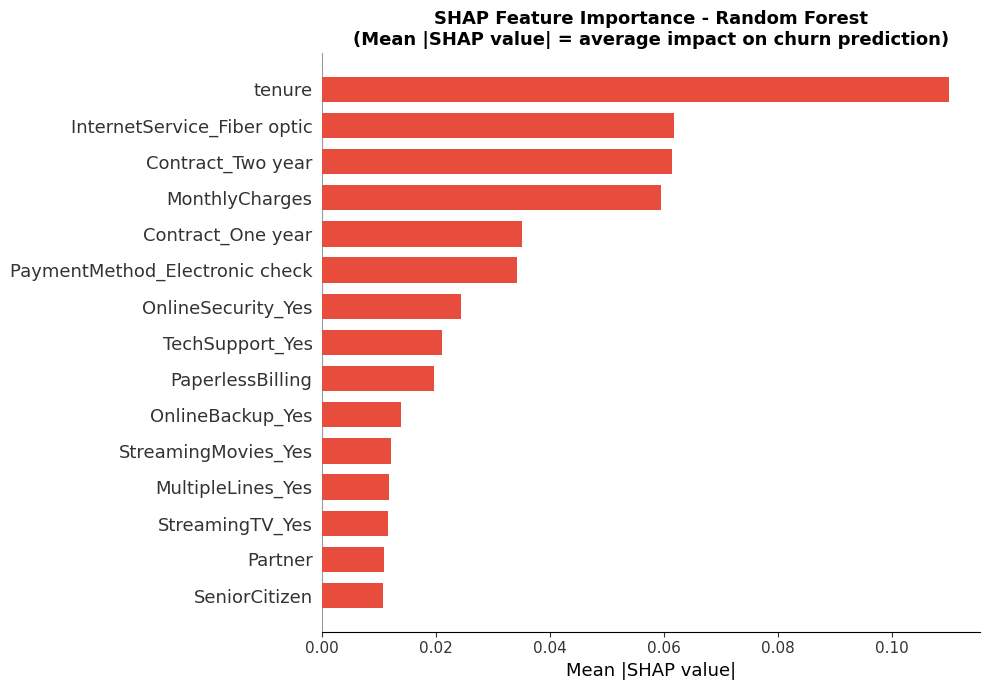

In [46]:
fig, ax = plt.subplots(figsize=(10, 7))

shap.summary_plot(
    shap_churn,
    X_test,
    plot_type='bar',
    max_display=15,
    show=False,
    plot_size=None,
    color='#e74c3c'
)

plt.title('SHAP Feature Importance - Random Forest\n'
          '(Mean |SHAP value| = average impact on churn prediction)',
          fontsize=13, fontweight='bold')
plt.xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.show()

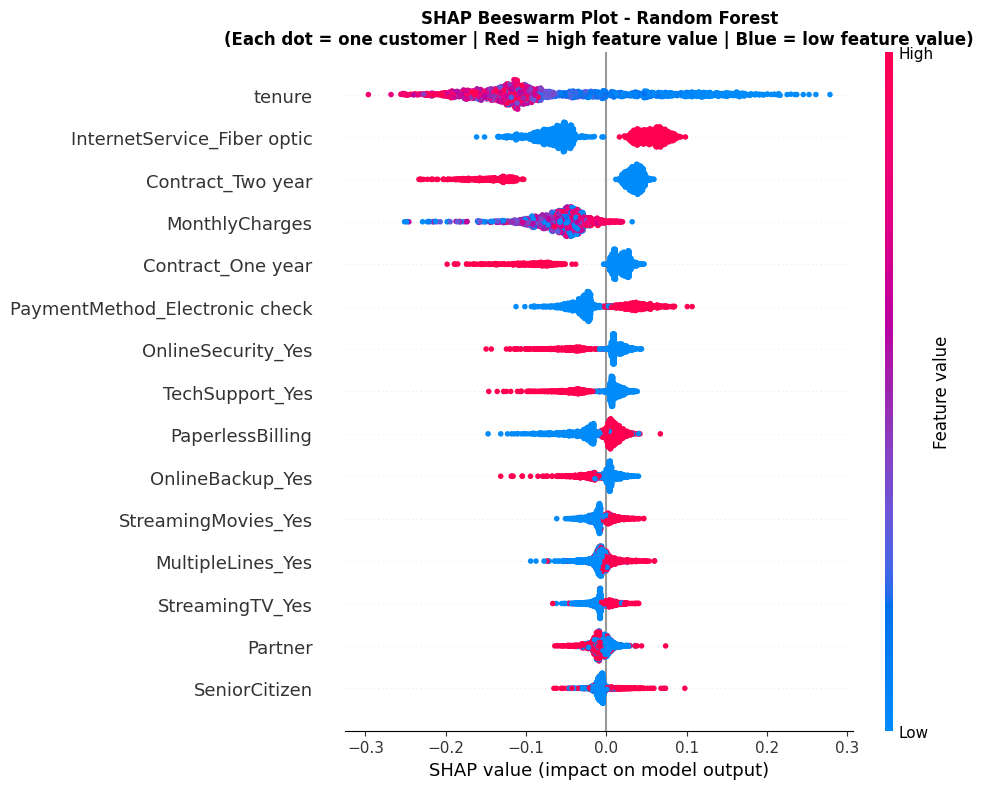

In [47]:
fig, ax = plt.subplots(figsize=(10, 8))

shap.summary_plot(
    shap_churn,
    X_test,
    max_display=15,
    show=False,
    plot_size=None
)

plt.title('SHAP Beeswarm Plot - Random Forest\n'
          '(Each dot = one customer | '
          'Red = high feature value | Blue = low feature value)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

   FEATURE IMPORTANCE COMPARISON: SHAP vs MDI vs LR
 SHAP Rank                           SHAP                            MDI                      LR |coef|
         1                         tenure                         tenure              Contract_Two year
         2    InternetService_Fiber optic                 MonthlyCharges    InternetService_Fiber optic
         3              Contract_Two year              Contract_Two year                         tenure
         4                 MonthlyCharges    InternetService_Fiber optic              Contract_One year
         5              Contract_One year PaymentMethod_Electronic check                 MonthlyCharges
         6 PaymentMethod_Electronic check              Contract_One year            StreamingMovies_Yes
         7             OnlineSecurity_Yes             OnlineSecurity_Yes                StreamingTV_Yes
         8                TechSupport_Yes               PaperlessBilling PaymentMethod_Electronic check
         9  

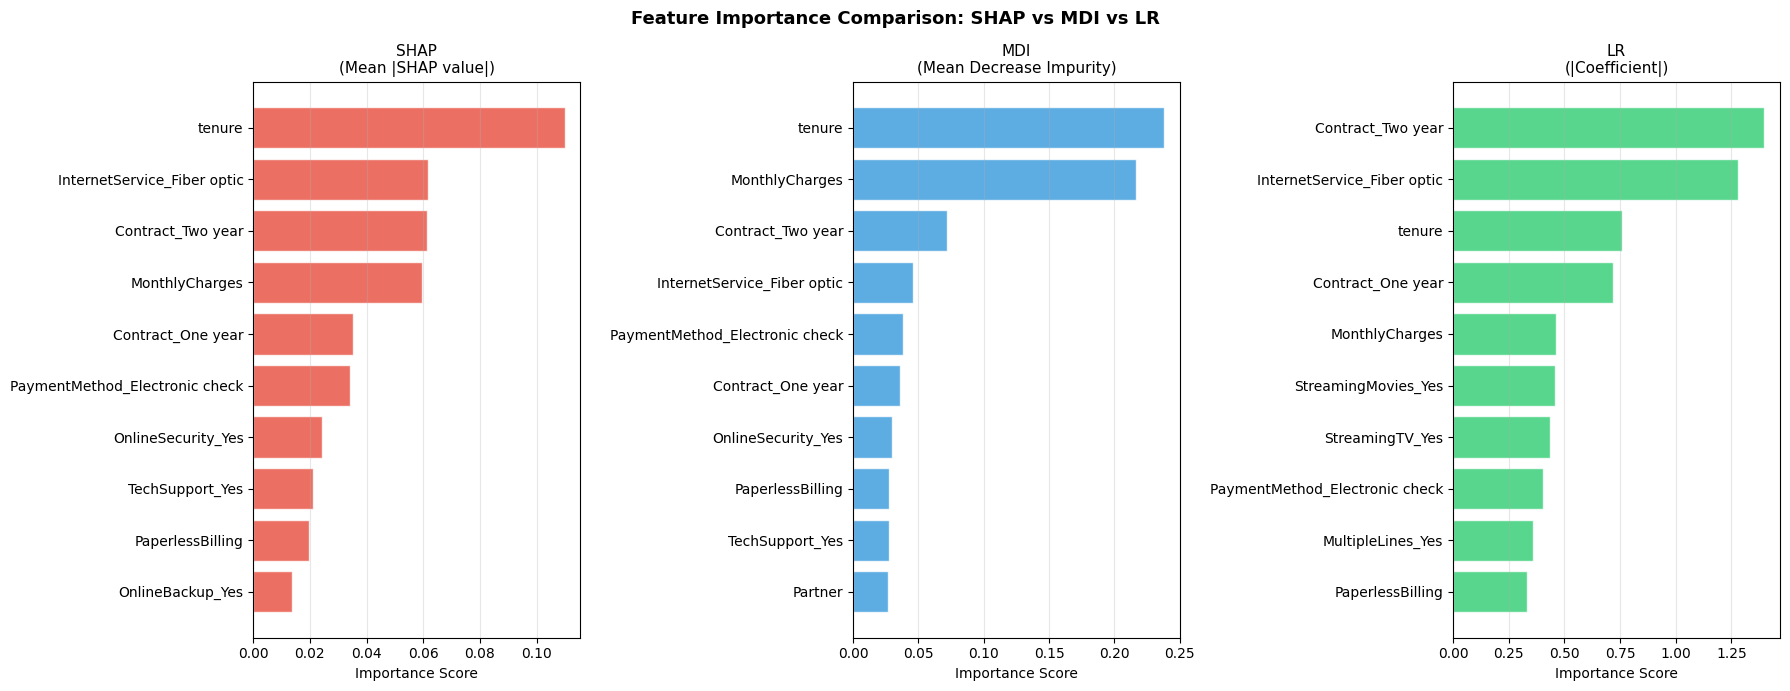

In [48]:
# Build importance series for all three methods
shap_importance = pd.Series(
    np.abs(shap_churn).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=False)

mdi_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

lr_importance = pd.Series(
    np.abs(lr_model.coef_[0]),
    index=X_train.columns
).sort_values(ascending=False)

# Top 10 for each method
comparison = pd.DataFrame({
    'SHAP Rank' : range(1, 11),
    'SHAP'      : shap_importance.head(10).index.tolist(),
    'MDI'       : mdi_importance.head(10).index.tolist(),
    'LR |coef|' : lr_importance.head(10).index.tolist()
})

print("="*75)
print("   FEATURE IMPORTANCE COMPARISON: SHAP vs MDI vs LR")
print("="*75)
print(comparison.to_string(index=False))
print("="*75)

# Check agreement across all three methods
print("\nAgreement on Top 5 features across all methods:")
top5_shap = set(shap_importance.head(5).index)
top5_mdi  = set(mdi_importance.head(5).index)
top5_lr   = set(lr_importance.head(5).index)
common    = top5_shap & top5_mdi & top5_lr
print(f"  Common features: {common}")

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Feature Importance Comparison: SHAP vs MDI vs LR',
             fontsize=13, fontweight='bold')

for ax, imp, name, color in zip(
    axes,
    [shap_importance, mdi_importance, lr_importance],
    ['SHAP\n(Mean |SHAP value|)',
     'MDI\n(Mean Decrease Impurity)',
     'LR\n(|Coefficient|)'],
    ['#e74c3c', '#3498db', '#2ecc71']
):
    top10 = imp.head(10)
    ax.barh(top10.index[::-1], top10.values[::-1],
            color=color, alpha=0.8, edgecolor='white')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Importance Score')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [49]:
!pip install xgboost -q
from xgboost import XGBClassifier

# scale_pos_weight = ratio of majority/minority class
pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"scale_pos_weight: {pos_weight:.2f}")

xgb_model = XGBClassifier(
    n_estimators     = 200,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = pos_weight,
    random_state     = 42,
    eval_metric      = 'logloss',
    verbosity        = 0
)

xgb_model.fit(X_train, y_train)

print("✅ XGBoost trained successfully.")
print(f"   Trees            : {xgb_model.n_estimators}")
print(f"   Max depth        : {xgb_model.max_depth}")
print(f"   Learning rate    : {xgb_model.learning_rate}")
print(f"   Scale pos weight : {pos_weight:.2f}")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\dioni\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


scale_pos_weight: 2.77
✅ XGBoost trained successfully.
   Trees            : 200
   Max depth        : 4
   Learning rate    : 0.05
   Scale pos weight : 2.77


In [50]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, roc_auc_score)

cv      = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Run cross-validation for XGBoost
print("Running XGBoost Cross-Validation...")
xgb_cv = cross_validate(xgb_model, X_train, y_train,
                         cv=cv, scoring=scoring, n_jobs=-1)

# Generate predictions on test set
xgb_pred      = xgb_model.predict(X_test)
xgb_pred_prob = xgb_model.predict_proba(X_test)[:, 1]

# Build full comparison table
def get_metrics(name, y_true, y_pred, y_prob):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 3),
        'Precision': round(precision_score(y_true, y_pred), 3),
        'Recall'   : round(recall_score(y_true, y_pred), 3),
        'F1-Score' : round(f1_score(y_true, y_pred), 3),
        'ROC-AUC'  : round(roc_auc_score(y_true, y_prob), 3)
    }

results_full = pd.DataFrame([
    get_metrics('Logistic Regression', y_test, lr_pred,  lr_pred_prob),
    get_metrics('Random Forest',       y_test, rf_pred,  rf_pred_prob),
    get_metrics('XGBoost',             y_test, xgb_pred, xgb_pred_prob),
]).set_index('Model')

print("\n" + "="*65)
print("        FULL 3-MODEL COMPARISON - TEST SET")
print("="*65)
print(results_full.to_string())
print("="*65)

# Cross-validation summary for all three models
print("\n=== 10-FOLD CROSS-VALIDATION SUMMARY ===\n")
for name, scores in [
    ('Logistic Regression', cv_results['Logistic Regression']),
    ('Random Forest',       cv_results['Random Forest']),
    ('XGBoost',             xgb_cv)]:
    auc = scores['test_roc_auc']
    rec = scores['test_recall']
    f1  = scores['test_f1']
    print(f"{name:<22}: "
          f"AUC={auc.mean():.3f}+-{auc.std():.3f} | "
          f"Recall={rec.mean():.3f}+-{rec.std():.3f} | "
          f"F1={f1.mean():.3f}+-{f1.std():.3f}")

results_full.style\
    .highlight_max(axis=0, color='#d4edda')\
    .highlight_min(axis=0, color='#f8d7da')\
    .format("{:.3f}")

Running XGBoost Cross-Validation...

        FULL 3-MODEL COMPARISON - TEST SET
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression     0.743      0.511   0.778     0.617    0.839
Random Forest           0.781      0.613   0.479     0.538    0.820
XGBoost                 0.746      0.514   0.783     0.621    0.842

=== 10-FOLD CROSS-VALIDATION SUMMARY ===

Logistic Regression   : AUC=0.845+-0.014 | Recall=0.792+-0.035 | F1=0.626+-0.025
Random Forest         : AUC=0.818+-0.016 | Recall=0.477+-0.038 | F1=0.541+-0.029
XGBoost               : AUC=0.847+-0.014 | Recall=0.788+-0.021 | F1=0.629+-0.015


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.743,0.511,0.778,0.617,0.839
Random Forest,0.781,0.613,0.479,0.538,0.820
XGBoost,0.746,0.514,0.783,0.621,0.842


C:\Users\dioni\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\dioni\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\dioni\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\dioni\AppData\Local\Temp\ipykernel_19044\2672664791.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name

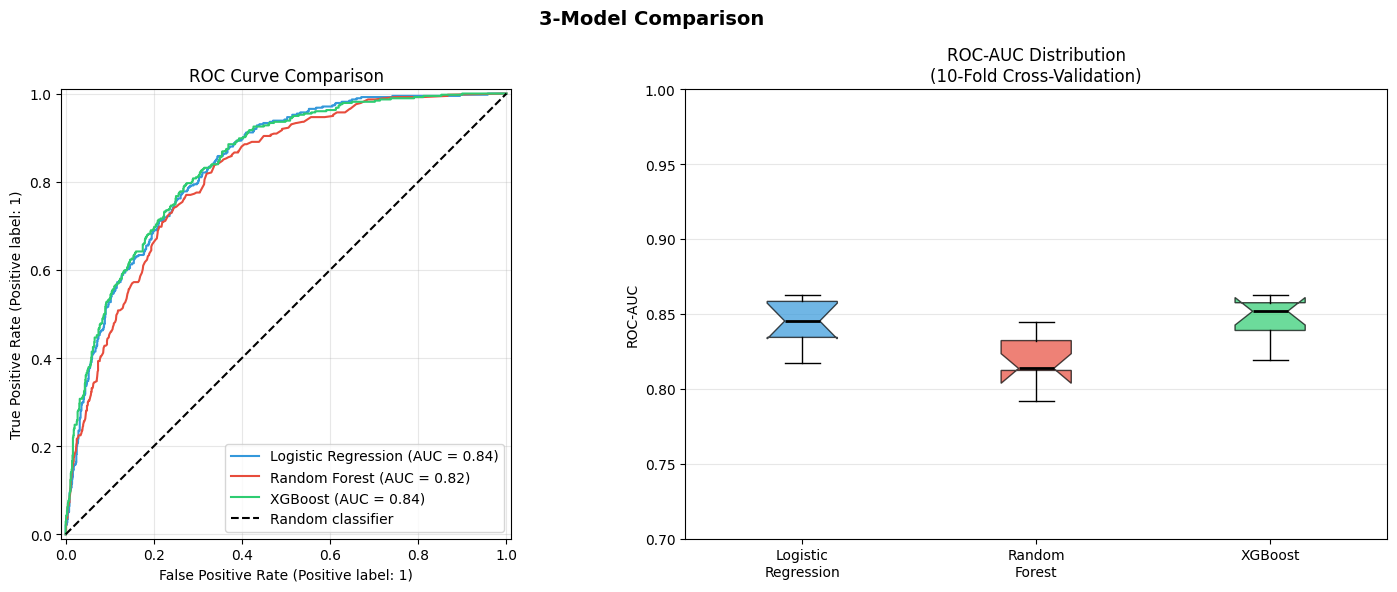

In [51]:
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('3-Model Comparison', fontsize=14, fontweight='bold')

# ROC curves for all three models
for model, name, color in [
    (lr_model,  'Logistic Regression', '#3498db'),
    (rf_model,  'Random Forest',       '#e74c3c'),
    (xgb_model, 'XGBoost',             '#2ecc71')]:
    RocCurveDisplay.from_estimator(
        model, X_test, y_test,
        ax=axes[0], name=name, color=color)

axes[0].plot([0,1],[0,1],'k--', label='Random classifier')
axes[0].set_title('ROC Curve Comparison')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# AUC distribution across 10 folds
auc_data = [
    cv_results['Logistic Regression']['test_roc_auc'],
    cv_results['Random Forest']['test_roc_auc'],
    xgb_cv['test_roc_auc']
]

bp = axes[1].boxplot(
    auc_data,
    labels=['Logistic\nRegression', 'Random\nForest', 'XGBoost'],
    patch_artist=True, notch=True,
    medianprops={'color': 'black', 'linewidth': 2})

for patch, color in zip(bp['boxes'],
                        ['#3498db', '#e74c3c', '#2ecc71']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title('ROC-AUC Distribution\n(10-Fold Cross-Validation)')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_ylim(0.70, 1.0)
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

   THRESHOLD OPTIMIZATION - Logistic Regression

  Default threshold  : 0.500
  Precision          : 0.511
  Recall             : 0.778
  F1                 : 0.617

  Optimal threshold  : 0.596
  Precision          : 0.548
  Recall             : 0.711
  F1                 : 0.619


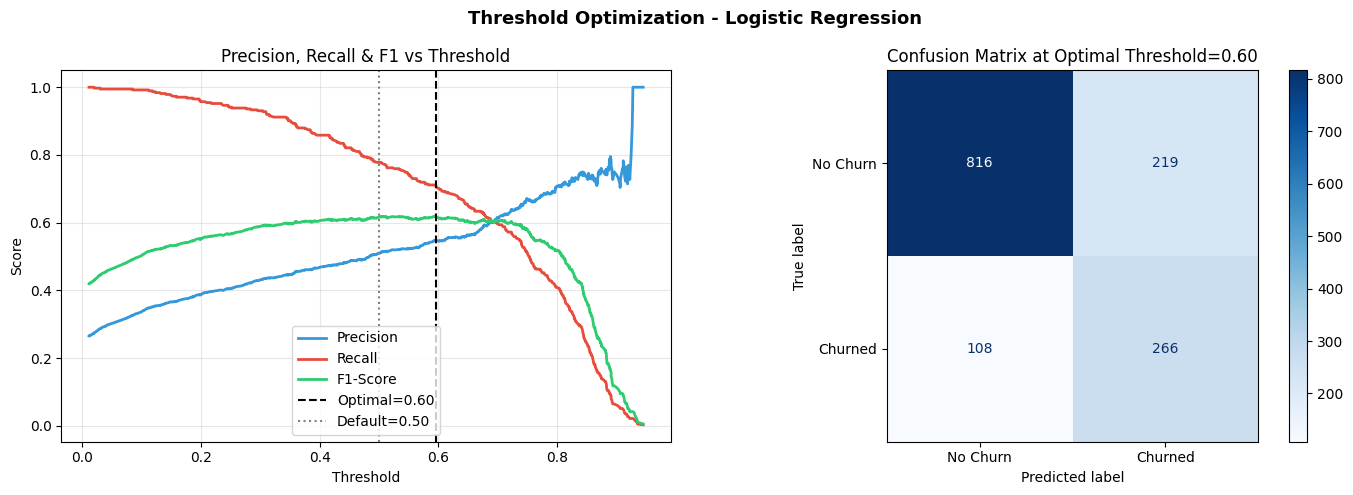

In [52]:
from sklearn.metrics import (precision_recall_curve,
                              precision_score, recall_score,
                              f1_score, ConfusionMatrixDisplay)

# Compute precision, recall and F1 across all thresholds
precisions, recalls, thresholds = precision_recall_curve(
    y_test, lr_pred_prob)

# Find threshold that maximizes F1
f1_scores   = 2*(precisions*recalls)/(precisions+recalls+1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_thr = thresholds[optimal_idx]

# Apply optimal threshold
lr_pred_opt = (lr_pred_prob >= optimal_thr).astype(int)

print("="*50)
print("   THRESHOLD OPTIMIZATION - Logistic Regression")
print("="*50)
print(f"\n  Default threshold  : 0.500")
print(f"  Precision          : "
      f"{precision_score(y_test, lr_pred):.3f}")
print(f"  Recall             : "
      f"{recall_score(y_test, lr_pred):.3f}")
print(f"  F1                 : "
      f"{f1_score(y_test, lr_pred):.3f}")
print(f"\n  Optimal threshold  : {optimal_thr:.3f}")
print(f"  Precision          : "
      f"{precision_score(y_test, lr_pred_opt):.3f}")
print(f"  Recall             : "
      f"{recall_score(y_test, lr_pred_opt):.3f}")
print(f"  F1                 : "
      f"{f1_score(y_test, lr_pred_opt):.3f}")
print("="*50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Threshold Optimization - Logistic Regression',
             fontsize=13, fontweight='bold')

# Plot Precision, Recall and F1 across all thresholds
axes[0].plot(thresholds, precisions[:-1],
             '#3498db', label='Precision', linewidth=2)
axes[0].plot(thresholds, recalls[:-1],
             '#e74c3c', label='Recall',    linewidth=2)
axes[0].plot(thresholds, f1_scores[:-1],
             '#2ecc71', label='F1-Score',  linewidth=2)
axes[0].axvline(x=optimal_thr, color='black',
                linestyle='--',
                label=f'Optimal={optimal_thr:.2f}')
axes[0].axvline(x=0.50, color='gray',
                linestyle=':', label='Default=0.50')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision, Recall & F1 vs Threshold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Confusion matrix at optimal threshold
ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred_opt,
    display_labels=['No Churn', 'Churned'],
    cmap='Blues', ax=axes[1])
axes[1].set_title(
    f'Confusion Matrix at Optimal Threshold={optimal_thr:.2f}')

plt.tight_layout()
plt.show()